# Import

In [1]:
import torch
import transformers
import matplotlib.pyplot as plt
from tqdm import tqdm

device = 0 if torch.cuda.is_available() else -1
print(device)

0


In [2]:
cd ../

/sise/home/shistikk/IndicatorsOfResilience/code


/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
from qlatent.qmlm.qmlm_torch import *
from qlatent.qmlm.qmlm_torch import QMLM

2024-12-05 11:34:33.381921: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-05 11:34:34.869344: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
# softmax_files = [False, True]
# softmax_files = [True]

def split_question(Q, index, scales, softmax, filters):
  result = []
  for s in scales:
    q = QCACHE(Q(index=index, scale=s))
    for sf in softmax:
      for f in filters:
        if sf:            
            qsf = QSOFTMAX(q,dim=[index[0], s])
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print((index, s),sf,f)
            result.append(qsf_f)
            
            qsf = QSOFTMAX(q,dim=s)
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(s,sf,f)
            result.append(qsf_f)
            
            qsf = QSOFTMAX(q,dim=index[0])
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(index[0],sf,f)
            result.append(qsf_f)
        else:
            qsf = QPASS(q,descupdate={'softmax':''})
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(s,sf,f)
            result.append(qsf_f)
  return result

def dict_pos_neg(pos, neg, w):
  return dict(dict_same_weight(1.0*w/len(pos),pos), **dict_same_weight(-1.0*w/len(neg),neg))

def print_permutations(q):
#     for q in Q1s:
    W = q._pdf['W']
    print(q._descriptor)
    for i, (kmap, w) in enumerate(zip(q._keywords_map, W)):
        template = q._template.format_map(kmap)
#         context = q._context_template.format_map(kmap)
#         answer = q._answer_template.format_map(kmap)
#         sexisem_score = sexisem_classifier(context.strip('.') + ' ' +answer)
#         print(f'{i}.',context ,'->', answer, w)
        print(f'{i}.',template, w)
#     break


frequency_weights:SCALE = {
    'never':-4,
    'very rarely':-3,
    'seldom':-2,
    'rarely':-2,
    'frequently':2,
    'often':2,
    'very frequently':3,
    'always':4,    
}
    
intensifiers_fraction_without_none:SCALE={
            "few":1,
            "some":2,
            "many":3,
            "most":4,
            "all":5,
        }
    
binary_frequency_weights = {k: 1 if v > 0 else -1 for k, v in frequency_weights.items()}
rbinary_frequency_weights = {k: -1 if v > 0 else 1 for k, v in frequency_weights.items()}
frequency_pos = [k for k, v in frequency_weights.items() if v > 0]
frequency_neg = [k for k, v in frequency_weights.items() if v < 0]

# Load Model

In [5]:
p = "distilbert-base-uncased"
mlm = pipeline("fill-mask",device=0, model=p)
mlm.model_identifier = p

# from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW
# tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
# optimizer = AdamW(mlm.model.parameters(), lr=2e-5, weight_decay=0.01)

# Initial Gradients

In [6]:
# # Print initial gradients (should be None)
# print("Initial Gradients:")
# for name, param in mlm.model.named_parameters():
#     if param.grad is not None:
#         print(f'Gradient for {name}: {param.grad}')
#     else:
#         print(f'Gradient for {name}: None')

# PHQ9 Questionnaire

## PHQ1

In [7]:
# emo_pos=['little interest', 'displeasure', 'dissatisfaction']
# emo_neg=['pleasure', 'satisfaction']
emo_pos = ['unsatisfied', 'upset', 'annoyed']
emo_neg = ['pleased', 'happy', 'satisfied']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q1(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             template = "Over the last 2 weeks, I had {frequency} experienced {index} in doing things.",
            template = "Over the last 2 weeks, I have {frequency} been {index} in doing things.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":1,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Little interest or pleasure in doing things'
            },
            **kwargs
        )
PHQ9Q1s = split_question(PHQ9Q1,  
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q1().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q1 =PHQ9Q1s[i]
# q1.run(mlm).report()
# print_permutations(q1)

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly


In [8]:
# q1.run(mlm)

In [9]:
# effect_size = q1.effect_size() * -1
# effect_size = effect_size.to(device)       

# optimizer.zero_grad()
# effect_size.backward()
# optimizer.step()

In [10]:
# # Print gradients after backpropagation
# print("\nGradients after Backpropagation:")
# for name, param in mlm.model.named_parameters():
#     if param.grad is not None:
#         print(f'Gradient for {name}: {param.grad}')
#     else:
#         print('None')

## PHQ2

In [11]:
emo_pos=['down', 'depressed', 'hopeless', 'sad']
emo_neg=['happy', 'hopeful', 'cheerful']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q2(QMLM):
    def __init__(self, **kwargs ):
        super().__init__(
#             context_template="Over the last 2 weeks, I have been feeling {index}.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I was {frequency} feeling {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":2,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling down, depressed or hopeless'
            },
            **kwargs
        )
PHQ9Q2s = split_question(PHQ9Q2,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q2().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q2 = PHQ9Q2s[i]
# q.run(mnli).report()


(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ3

In [12]:
emo_pos=['had trouble falling asleep', 'had trouble staying asleep']
emo_neg=['been resting well', 'been sleeping well']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q3(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I {frequency} had trouble falling asleep.",
#             answer_template="This sentence is {index}.",
            template = "Over the last 2 weeks, I have {frequency} {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":3,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble falling asleep, staying asleep, or sleeping too much'
            },
            **kwargs
        )
PHQ9Q3s = split_question(PHQ9Q3,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q3().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q3=PHQ9Q3s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ4

In [13]:
emo_pos=['tired', 'drained', 'fatigued']
emo_neg=['energized', 'refreshed', 'lively']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q4(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I feel {index}.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} felt {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":4,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling tired or having little energy'
            },
            **kwargs
        )
PHQ9Q4s = split_question(PHQ9Q4,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q4().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q4=PHQ9Q4s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ5

In [14]:
emo_pos=['poor appetite', 'been overeating']
emo_neg=['healthy appetite', 'satisfying appetite']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q5(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I had {index}",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I {frequency} had a {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":5,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Poor appetite or overeating'
            },
            **kwargs
        )
PHQ9Q5s = split_question(PHQ9Q5,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q5().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q5=PHQ9Q5s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ6

In [15]:
emo_pos=['a failure', 'a disappointment', 'letting myself down', 'letting my family down']
emo_neg=['successful', 'lucky', 'confident']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q6(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I feel {index}.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} felt that I am {index}.",            
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":6,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling bad about yourself - or that you’re a failure or have let yourself or your family down'
            },
            **kwargs
        )
PHQ9Q6s = split_question(PHQ9Q6,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q6().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q6=PHQ9Q6s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ7

In [16]:
emo_pos=['have trouble concentrating', 'have difficulty focusing']
emo_neg=['concentrate easily', 'focus effortlessly']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q7(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I {frequency} had trouble concentrating.",
#             answer_template="This sentence is {index}.",
            template = "Over the last 2 weeks, I {frequency} {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":7,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble concentrating on things, such as reading the newspaper or watching television'
            },
            **kwargs
        )
PHQ9Q7s = split_question(PHQ9Q7,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q7().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q7=PHQ9Q7s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ8

In [17]:
emo_pos=['fidgetly', 'slowly']
emo_neg=['normally', 'naturally']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q8(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I move or speak {index}.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} moved or spoken {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":8,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Moving or speaking so slowly that other people could have noticed. Or, the opposite - being so fidgety or restless that you have been moving around a lot more than usual'
            },
            **kwargs
        )
PHQ9Q8s = split_question(PHQ9Q8,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q8().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q8=PHQ9Q8s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## PHQ9

In [18]:
emo_pos=['suicidal', 'self destructive']
emo_neg=['harmless', 'hopeful', 'positive']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q9(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I have {index} thoughts.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} had {index} thoughts.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":9,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Thoughts that you would be better off dead or of hurting yourself in some way'
            },
            **kwargs
        )
PHQ9Q9s = split_question(PHQ9Q9,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q9().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q9=PHQ9Q9s[i]
# q9.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# GAD7 Questionnaire

In [19]:
softmax_files = [True, False]

## GAD1

In [20]:
emo_pos=['nervous', 'anxious', 'on edge'] #agitated
emo_neg=['calm', 'peaceful', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q1(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I feel {index}.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I was {frequency} feeling {index}.",
           dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":1,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling nervous, anxious or on edge'
            },
            **kwargs
        )
GAD7Q1s = split_question(GAD7Q1,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q1().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q1s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD2

In [21]:
# emo_pos=['nervous', 'bothered', 'disturbed']
# emo_neg=['peaceful','calm', 'relaxed']
emo_pos = ['worried', 'troubled', 'disturbed']
emo_neg = ['peaceful','calm', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q2(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I was {index}.",
#             answer_template="It is {frequency} correct.",
#             template = "Over the last 2 weeks, I have {frequency} been {index}.",
            template = "Over the last 2 weeks, I have {frequency} been {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
              "Factor":"GAD7",
              "Ordinal":2,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Not being able to stop or control worrying'
            },
            **kwargs
        )

GAD7Q2s = split_question(GAD7Q2,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q2().get_filter_for_postive_keywords(['frequency'])
                      },
                      )

i = 0
q=GAD7Q2s[i]
# q.run(mnli).report()

# q=GAD7Q2s[i]
# q.run(mnli2).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD3

In [22]:
emo_pos=['worried', 'stressed', 'nervous']
emo_neg=['confident', 'tranquil']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q3(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I felt {index} about different things.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} been {index} about different things.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":3,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Worrying too much about different things'
            },
            **kwargs
        )
GAD7Q3s = split_question(GAD7Q3,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q3().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q3s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD4

In [23]:
emo_pos=['trouble', 'difficulty', ]
emo_neg=['an effortless time', 'an easy time']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q4(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I've been having {index} relaxing.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} had {index} relaxing.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":4,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble relaxing'
            },
            **kwargs
        )
GAD7Q4s = split_question(GAD7Q4,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q4().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q4s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD5

In [24]:
emo_pos=['restless', 'agitated', 'nervous']
emo_neg=['calm', 'peaceful', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q5(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I felt {index}.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} felt {index}.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":5,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Being so restless that it is hard to sit still'
            },
            **kwargs
        )
GAD7Q5s = split_question(GAD7Q5,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q5().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q5s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD6

In [25]:
emo_pos=['annoyed', 'irritated', 'frustrated', 'bothered']
emo_neg=['calm', 'tranquil', 'peaceful', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q6(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I became {index}.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} felt {index}.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":6,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Becoming easily annoyed or irritable'
            },
            **kwargs
        )
GAD7Q6s = split_question(GAD7Q6,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q6().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q6s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD7

In [26]:
emo_pos=['afraid of', 'scared of']
emo_neg=['calm about', 'tranquil about', 'relaxed about']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q7(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
#             context_template="Over the last 2 weeks, I felt {index} about upcoming events.",
#             answer_template="It is {frequency} correct.",
            template = "Over the last 2 weeks, I have {frequency} felt {index} upcoming events.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":7,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling afraid as if something awful might happen'
            },
            **kwargs
        )
GAD7Q7s = split_question(GAD7Q7,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q7().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q7s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# SOC13 Questionnaire

## SOC4

In [27]:
kw_attitude_neg = ["meaningless", "dull", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling"]
# kw_attitude_pos = ["indifferent to", "apathetic to"]
# kw_attitude_neg = ["caring about", "interested in"]
dict_attitude = dict_pos_neg(kw_attitude_pos,kw_attitude_neg, 1.0)

class SOCQ4(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="What goes around me is {index} to me.",
#         answer_template="It is {frequency} correct.",
        template = "What happens around me is {frequency} {index} to me.",
#         template = "I am {frequency} {index} what goes on around me.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":4,
                      "Original":"Do you have the feeling that you don’t really care what goes on around you? "
        },
        **kwargs,
    )
SOCQ4s = split_question(SOCQ4,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ4().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ4s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC5

In [28]:
kw_attitude_neg = ['surprised by','puzzled by', ]
kw_attitude_pos = ['expecting','anticipating']
# kw_attitude_neg = ['surprise' , 'puzzle' , 'stun']
# kw_attitude_pos = ['supported' , 'helped' , 'backed']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ5(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I am {frequency} {index} the behavior of people I thought I knew well.",
#         answer_template="True.", 
        template = "I am {frequency} {index} the behavior of people I thought I knew well.",
#         template = "The people whom I think I know well {frequency} {index} me.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":5,
                      "Original":"Has it happened in the past that you were surprised by the behavior of people whom you thought you knew well? "
        },
        **kwargs,
    )
SOCQ5s = split_question(SOCQ5,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ5().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ5s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC6

In [29]:
kw_attitude_neg = ["disappointed", 'failed']
kw_attitude_pos = ["supported", "helped" , 'backed']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ6(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="People whom I counted on {frequency} {index} me.",
#         answer_template="True.",
        template = "The people I counted on {frequency} {index} me.",
        
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":6,
                      "Original":"Has it happened that people whom you counted on disappointed you? "
        },
        **kwargs,
    )
SOCQ6s = split_question(SOCQ6,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ6().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ6s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC8

In [30]:
# kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
# kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
kw_attitude_pos = ["clear", "definite", 'precise']
kw_attitude_neg = ["vague", "uncertain", "unclear"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ8(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="My life are {index}.",
#         answer_template="It is {frequency} correct.",
#         template = "My life is {frequency} {index}.",
        template="Until now my life {frequency} had {index} goals and purposes.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":8,
                      "Original":"Until now your life has had: "
        },
        **kwargs,
    )
SOCQ8s = split_question(SOCQ8,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ8().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ8s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC9

In [31]:
kw_attitude_neg = ["unfairly", "unjustly", "with discrimination", "unreasonably"]
kw_attitude_pos = ["fairly", "justly", "properly"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ9(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I feel that I am being treated {index}.",
#         answer_template="It is {frequency} correct.",
        template = "I {frequency} feel that I am being treated {index}.",
        
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":9,
                      "Original":"Do you have the feeling that you’re being treated unfairly? "
        },
        **kwargs,
    )
SOCQ9s = split_question(SOCQ9,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ9().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ9s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC12

In [32]:
kw_attitude_neg = ["helpless", "hopeless", 'powerless']
kw_attitude_pos = ["easy", "comfortable", 'known']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ12(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__( 
#         context_template="In unfamiliar situation I feel {index}.",
#         answer_template="It is {frequency} correct.",
        template = "In an unfamiliar situation I {frequency} feel {index}.",
        
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":12,
                      "Original":"Do you have the feeling that you’re in an unfamiliar situation and don’t know what to do?"
        },
        **kwargs,
    )
SOCQ12s = split_question(SOCQ12,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ12().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ12s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC16

In [33]:
# kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
# kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
kw_attitude_pos = ["pleasure", "satisfaction", 'fulfillment']
kw_attitude_neg = ["pain", "boredom", 'agony']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ16(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="Things I do every day are {index}.",
#         answer_template="It is {frequency} correct.",
#         template = "The things I do every day are {frequency} {index}.",
        template="Doing things I do every day is {frequency} a source of {index}.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":16,
                      "Original":"Doing the things you do every day is: "
        },
        **kwargs,
    )
SOCQ16s = split_question(SOCQ16,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ16().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ16s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC19

In [34]:
kw_attitude_pos = ["clear", "coherent", 'definite']
kw_attitude_neg = ["mixed-up", "confounded"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ19(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I have {index} feelings and ideas.",
#         answer_template="It is {frequency} correct.",
        template = "I {frequency} have {index} feelings and ideas.",
        
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":19,
                      "Original":"Do you have very mixed-up feelings and ideas? "
        },
        **kwargs,
    )
SOCQ19s = split_question(SOCQ19,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ19().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ19s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC21

In [35]:
# kw_attitude_neg = ["unwanted", 'undesired']
# kw_attitude_pos = ['joyful', 'good',]
kw_attitude_pos = ['face', 'confront', 'acknowledge', 'process', 'accept']
kw_attitude_neg = [ 'ignore', 'avoid', 'dismiss']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ21(QMLM):
  """
  """

  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I have {index} feelings.",
#         answer_template="It is {frequency} correct.",
#         template = "I {frequency} have {index} feelings inside of me.",        
        template="I {frequency} have feelings inside I would like to {index}.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":21,
                      "Original":"Does it happen that you have feelings inside you would rather not feel? "
        },
        **kwargs,
    )
SOCQ21s = split_question(SOCQ21,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ21().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ21s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC25

In [36]:
kw_attitude_neg = ["loser", "failure", 'disappointment']
kw_attitude_pos = ["winner", "success"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ25(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I’m a {index}.",
#         answer_template="It is {frequency} correct.",
        template = "I {frequency} feel like a {index}.",
        
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":25,
                      "Original":"Many people—even those with a strong character—sometimes feel like sad sacks (losers) in certain situations. How often have you felt this way in the past? "
        },
        **kwargs,
    )
SOCQ25s = split_question(SOCQ25,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ25().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ25s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC26

In [37]:
kw_attitude_pos = ["estimate in proportion", "judge in proportion",]
kw_attitude_neg = ["overestimate",'underestimate', 'misjudge']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ26(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I {index} the importence of something that happened.",
#         answer_template="It is {frequency} correct.",
#         template = "I {frequency} {index} the importance of things that happen.",
        template = "I {frequency} {index} how important the things that happen are.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":26,
                      "Original":"When something happened‚ you have generally found that: you overestimated or underestimated its importance, you saw things in the right proportion"
        },
        **kwargs,
    )
SOCQ26s = split_question(SOCQ26,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ26().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ26s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC28

In [38]:
kw_attitude_neg = ["meaningless", "pointless", "aimless", ]
kw_attitude_pos = ["meaningful", "important", 'essential', ]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ28(QMLM):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="The things I do in my daily life are {index} to me.",
#         answer_template="It is {frequency} correct.",
#         template = "The things I do in my daily life are {frequency} {index}.",
        template="I {frequency} feel that things I do in my daily life are {index}.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":28,
                      "Original":"How often do you have the feeling that there’s little meaning in the things you do in your daily life? "
        },
        **kwargs,
    )
SOCQ28s = split_question(SOCQ28,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ28().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ28s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC29

In [39]:
kw_attitude_neg = ["out of control", "uncontrollable", 'unmanageable' ]
kw_attitude_pos = ["contained", "collected", 'controlled']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class SOCQ29(QMLM):
  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I feel that my feelings are {index}.",
#         answer_template="It is {frequency} correct.",
        template = "I {frequency} feel that my feelings are {index}.",
        
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":29,
                      "Original":"How often do you have feelings that you’re not sure you can keep under control? "
        },
        **kwargs,
    )
SOCQ29s = split_question(SOCQ29,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ29().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ29s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# Neuroticism

## BIG5   13

In [40]:
kw_attitude_pos = ['stressed', 'worried']
kw_attitude_neg = ['calm', 'at peace']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class BIG5Q13(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
            template = "I {frequency} feel {index} about things.",
            dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
            descriptor = {"Questionnair":"BIG5",
              "Factor":"Neuroticism",
              "Ordinal":13,
            "Original":"I am easily stressed and worry about things."
            },
            **kwargs
        )
BIG5Q13s = split_question(BIG5Q13,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly":BIG5Q13().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q=BIG5Q13s[i]
# q.run(mlm).report()
# print_permutations(q)

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## BIG5   14

In [41]:
kw_attitude_pos = ['distressed', 'upset', 'volatile']
kw_attitude_neg = ['relaxed', 'composed', 'collected']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class BIG5Q14(QMLM):
    def __init__(self, **kwargs):
        super().__init__(
            template = "I {frequency} feel emotionally {index}.",
            dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
            descriptor = {"Questionnair":"BIG5",
              "Factor":"Neuroticism",
              "Ordinal":14,
            "Original":"I am easily upset and prone to mood swings."
            },
            **kwargs
        )
BIG5Q14s = split_question(BIG5Q14,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly":BIG5Q14().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q=BIG5Q14s[i]
# q.run(mlm).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# Validation of Translation

In [39]:
from pathlib import Path
import warnings
from sentence_transformers import SentenceTransformer, util
from collections import defaultdict

In [43]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [41]:
sentence_embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
cola = pipeline("text-classification","mrm8488/deberta-v3-small-finetuned-cola", device=device)

import os
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu

def linguistic_acceptabilities(q, index, scale,question_name, student_id, output_path=Path(''), save_to_file=False):
    score_by_cola_lst=[]
    score_of_semantic_distance_lst=[]
    score_by_bleu_lst=[]
    kmap_lst=[]
    question_name_lst=[]
    description = q._descriptor
    strFactor=description['Factor']
    strOrdinal=str(description.get('Ordinal', 0))
    ##cleaning the string to get the original question
    strOriginal= description['Original']
    strOriginal = 'none' if strOriginal is None else strOriginal
    strOriginal=strOriginal.replace(strFactor,'',1)
    strOriginal=strOriginal.replace(strOrdinal,'',1)
    strOriginal=strOriginal.replace('.','',1)
    strOriginal=strOriginal.strip() #the original question
    rows = []
    
    partial_internal_consistency = partial(q.internal_consistency, filter={}, index=index , scale=scale)
    try:
        silhouette_score = partial_internal_consistency(measure='silhouette_score', metric='correlation')
    except Exception as e:
        print(e)
        print('silhouette_score is set to -1')
        silhouette_score = -1
        
    if hasattr(q, 'linguistic_acceptability'):
        q.linguistic_acceptability['silhouette_score'] = silhouette_score
        return q.linguistic_acceptability

    for kmap in q._keywords_map:
        score = {}
        score['question_name'] = question_name
        query = q._descriptor['query'].format_map(kmap)
#         answer = q._answer_template.format_map(kmap)
        score['original_question'] = strOriginal


        cola_score = cola(query)[0].get('score')
        score['cola_score'] = cola_score
        score['param'] = kmap
        strPermutation= query
        # sentences = [context +" "+ answer]
        score['question_permutation'] = strPermutation
        #Compute embedding for both lists
        embeddings1 = sentence_embedding_model.encode(strOriginal, convert_to_tensor=True)
        embeddings2 = sentence_embedding_model.encode(strPermutation, convert_to_tensor=True)

        #Compute cosine-similarities
        cosine_scores = util.cos_sim(embeddings1, embeddings2)
        score['semantic_similarity'] = cosine_scores.item()

        score['silhouette_score'] = silhouette_score
        rows.append(score)


    filename = output_path / 'linguistic_acceptabilities.csv'
    df = pd.DataFrame(rows)
    df['student_id'] = student_id
    df = df[['student_id', 'question_name','original_question', 'param','question_permutation','cola_score','semantic_similarity','silhouette_score']]
    if save_to_file:
        if filename.exists():
            df.to_csv(filename, index=False, header=None, mode='a', encoding='utf-8-sig')
        else:
            df.to_csv(filename, index=False, encoding='utf-8-sig')
#     print(f"Linguistic acceptabilities saved in {filename}")
    q.linguistic_acceptability = df
    return df

/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [42]:
def question_attributes(q):
    score = {}
    score['questionnair']=q._descriptor['Questionnair']
    score['factor']=q._descriptor['Factor']
    score['ordinal']=q._descriptor['Ordinal']
    score['scale']=q._descriptor['scale']
    score['index']=q._descriptor['index']
    score['filter']=q._descriptor['filter']
    score['softmax'] = q._descriptor['softmax']
    score["original"] = q._descriptor['Original']
    score['Q'] = f"{score['questionnair']}{score['factor']}{score['ordinal']}"
    
    score['context_template'] = q._descriptor['query']
    score['answer_template'] = q._descriptor['query']
    score['dimensions'] = q._dimensions
    score['model'] = q.model.model_identifier if q.model else ""
    return score

def get_question_features(q, student_id='student_id', output_path=Path(''), save_to_file=False):
    score = question_attributes(q)
    score['mean_score'] = q.mean_score()
    index= q._index
    scale= q._scale
    linguistic_df = linguistic_acceptabilities(q, index=index, scale=scale,question_name=score['Q'], student_id=student_id,
                                               output_path=output_path, save_to_file=save_to_file)
    row = linguistic_df[['cola_score','silhouette_score']].mean(axis=0)
    row_dict = dict(row)
    row_dict['semantic_similarity'] = linguistic_df['semantic_similarity'].quantile(0.75)
    score = score | row_dict
    return score

def extract_epoch(model_path):
    if 'epoch-' in model_path.name:
        i = model_path.name.find('epoch-')
        j = model_path.name.find('_', i)
        if j > 0:
            epoch = int(model_path.name[i+len('epoch-'):j])
        else:
            epoch = int(model_path.name[i+len('epoch-'):])
        
    elif 'checkpoint-' in model_path.name:
        i = model_path.name.find('checkpoint-')
        j = model_path.name.find('_', i)
        if j > 0:
            epoch = int(model_path.name[i+len('checkpoint-'):j])
        else:
            epoch = int(model_path.name[i+len('checkpoint-'):])
    else:
        epoch = 0
    return epoch

def extract_run(model_path):
    try:
        if 'run' in model_path.name:
            for part in model_path.name.split('_'):
                if 'run' in part:
                    return int(part.replace('run', ''))
        else:
            return -1
    except Exception as e:
        print(e)
        return -1

import json

def get_mnli_score(checkpoint_path):
    mnli_score_path = checkpoint_path / 'all_results.json'
    if not mnli_score_path.exists():
        mnli_score_path = checkpoint_path.parent / (checkpoint_path.name + '_mnli_eval') / 'all_results.json'
    if mnli_score_path.exists():
        with open(mnli_score_path) as f:
            return json.load(f)["eval_accuracy"]
    else:
        return -1
    
# def run_questions(questions, mnli_base, mnli_checkpoint, checkpoint, train_process, fintune_dataset, q_range=[5, 0]):
#     if mnli_base is not mnli_checkpoint:
#         take_classifier(mnli_base, mnli_checkpoint)
#     rows = []
#     for q_raw in tqdm(questions):
# #         qname = q_identifier(q)
# #         print(qname)
#         print(q_raw, mnli_checkpoint.model_identifier)
#         q = q_raw.run(mnli_checkpoint)
#         score = get_question_features(q)
#         score['epoch'] = extract_epoch(checkpoint)
#         score['train_process'] = train_process
#         score['dataset'] = fintune_dataset
#         score['run'] = extract_run(checkpoint.parent)
#         score['mnli_score'] = get_mnli_score(checkpoint)
#         score['range'] = (q._weights_flat.min(), q._weights_flat.max())
#         score['ASI_score'] = np.interp(score['mean_score'], [q._weights_flat.min(), q._weights_flat.max()], q_range)
#         rows.append(score)
#         gc.collect()
#         torch.cuda.empty_cache()
#     return rows


def run_questions(questions, mnli_checkpoint, train_process, fintune_dataset, q_range=[5, 0]):    
    rows = []
    checkpoint = Path(mnli_checkpoint.model_identifier)
    for q_raw in tqdm(questions):
        T = time.time()
        q = q_raw.run(mnli_checkpoint)
#         print('run question:', time.time() - T, 'sec')
        T = time.time()
        score = get_question_features(q)
#         print('get features:', time.time() - T, 'sec')
        score['epoch'] = extract_epoch(checkpoint)
        score['train_process'] = train_process
        score['dataset'] = fintune_dataset
        score['run'] = extract_run(checkpoint.parent)
        score['mnli_score'] = get_mnli_score(checkpoint)
        score['range'] = (q._weights_flat.min(), q._weights_flat.max())
        score['ASI_score'] = np.interp(score['mean_score'], [q._weights_flat.min(), q._weights_flat.max()], q_range)
        rows.append(score)
        gc.collect()
        torch.cuda.empty_cache()
    return rows


def calc_scores(questions, checkpoint, output_path, train_process, fintune_dataset, q_range=[5, 0]):
    fix_config(checkpoint)
    mnli_checkpoint = pipeline("fill-mask", str(checkpoint), device=device)
    mnli_checkpoint.model_identifier = str(checkpoint)
    rows = run_questions(questions, mnli_checkpoint, train_process, fintune_dataset=fintune_dataset, q_range=q_range)
    return rows

def add_epochs_to_rows(rows, mlm_epoch, mnli_checkpoint):
    for score in rows:
        score['mlm_epoch'] = mlm_epoch
        score['mnli_checkpoint'] = mnli_checkpoint
    return rows


def write_to_csv(rows, output_path):
    old_score_hostile_df = pd.DataFrame(rows)
    if output_path.exists():
        old_score_hostile_df.to_csv(output_path, index=False, header=None, mode='a')
    else:
        old_score_hostile_df.to_csv(output_path, index=False)

def fix_config(checkpoint):
    if checkpoint.exists():
        with open(checkpoint / 'config.json') as f:
            d1 = json.load(f)
        d1['id2label'] = {'0': 'entailment', '1': 'neutral', '2': 'contradiction'}
        d1['label2id'] = {'contradiction': 2, 'entailment': 0, 'neutral': 1}
        with open(checkpoint / 'config.json', 'w') as f:
            json.dump(d1, f)
    else:
        print(checkpoint, '#### Not exists ####')
        
def calc_for_all_models(Qs, q_range= [5, 0]):
    all_rows = []
    for p in tqdm(mnli_pipelines):
        print(p)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            rows = calc_scores(Qs, Path(p),  Path(p), '->'.join(['base']), 'hostile',
                               use_base_model=False, q_range=q_range)
            rows = add_epochs_to_rows(rows, 0, 0)
            all_rows += rows
    return pd.DataFrame(all_rows)

In [43]:
result_path = Path('../results/')
if not result_path.exists():
    os.makedirs(result_path)

In [44]:
mlm_pipelines = [
    'bert-base-uncased',
    'xlm-roberta-base',
    'bert-large-uncased',
    'roberta-base',
    'albert-base-v2',
    'distilroberta-base',
    'microsoft/deberta-base',
    'distilbert-base-uncased',
    'bert-base-cased',
    'bert-base-chinese',
    'xlm-roberta-large',
    'bert-base-multilingual-cased',
    'distilbert-base-multilingual-cased',
    'roberta-large',
    'camembert-base',
    'cl-tohoku/bert-base-japanese-whole-word-masking',
    'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext',
    'indolem/indobert-base-uncased',
    'emilyalsentzer/Bio_ClinicalBERT',
    'facebook/esm2_t6_8M_UR50D',
]

## Run Questions

In [114]:
# questions = GAD7Q1s + GAD7Q2s  + GAD7Q3s + GAD7Q4s + GAD7Q5s + GAD7Q6s + GAD7Q7s + PHQ9Q1s + PHQ9Q2s + PHQ9Q3s + PHQ9Q4s + PHQ9Q5s + PHQ9Q6s + PHQ9Q7s + PHQ9Q8s + PHQ9Q9s
# questions = SOCQ4s + SOCQ5s + SOCQ6s + SOCQ8s + SOCQ9s + SOCQ12s + SOCQ16s + SOCQ19s + SOCQ21s + SOCQ25s + SOCQ26s + SOCQ28s + SOCQ29s
# questions = Q2s + Q4s + Q5s + Q7s + Q10s + Q11s + Q15s + Q14s + Q16s + Q18s + Q21s
# questions += Q1s + Q6s + Q12s + Q13s + Q3s + Q9s + Q17s + Q20s + Q8s + Q19s + Q22s
# questions += BIG5Q13s + BIG5Q14s
questions = SOCQ6s
update = True

output_path = result_path / f'phq_gad_soc_neuro_mlm_v1.csv'
# [str(a) for a in Path('mnli_models/').glob('*_mnli')]
pipelines = mlm_pipelines

if output_path.exists():
    temp_df = pd.read_csv(output_path)
    indexes = temp_df.groupby(['model', 'Q']).count().index.values
    used_models = defaultdict(set)
    for k, v in indexes:
        used_models[k].add(v)
else:
    used_models = {}


for p in tqdm(pipelines):
    print(p)
#     if get_mnli_score(Path(p)) < 0.7 and p not in mnli_pipelines:
#         print('Skip:', p)
#         continue
    with warnings.catch_warnings():
        try:
            warnings.simplefilter("ignore")        
            if p in used_models and not update:
                pipline_questions = []
                for q in questions:
                    if question_attributes(q)['Q'] not in used_models[p]:
                        pipline_questions.append(q)
                    else:
                        print('skip', p, question_attributes(q)['Q'])
            else:
                pipline_questions = questions

            rows = calc_scores(pipline_questions, Path(p),  output_path, '->'.join(['base']), 'hostile',)
            rows = add_epochs_to_rows(rows, 0, 0)
            write_to_csv(rows, output_path) 
            gc.collect()
            torch.cuda.empty_cache()
        except Exception as e:
            print(e)

            
df = pd.read_csv(output_path)
df = df.drop_duplicates(subset=['filter','softmax','model','Q'], keep='last')
df.to_csv(output_path, index=False)

  0%|          | 0/20 [00:00<?, ?it/s]

bert-base-uncased
bert-base-uncased #### Not exists ####


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).

 38%|███▊      | 3/8 [00:03<00:05,  1.16s/it]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
silhouette_score is set to -1



 50%|█████     | 4/8 [00:04<00:04,  1.07s/it]

...


 62%|██████▎   | 5/8 [00:01<00:00,  3.56it/s]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
silhouette_score is set to -1



 88%|████████▊ | 7/8 [00:02<00:00,  3.90it/s]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
silhouette_score is set to -1



100%|██████████| 20/20 [02:28<00:00,  7.40s/it]


In [45]:
import pingouin as pg

In [46]:
def load_results(csv_path, softmax, positiveonly, value='ASI_score', index='model', colums='Q'):
    df = pd.read_csv(csv_path)
    df['model'] = df['model'].str.replace('/dt/puzis/cnalab/maor/', '')
    if df['softmax'].isna().sum() > 0:
        softmax_filter = df['softmax'].isna()
    else:
        softmax_filter = df['softmax'] == ''
    if softmax:
        df = df[df['softmax'] == str(softmax)]
    else:
        df = df[softmax_filter]
    if value != 'silhouette_score':
        pass
    else:
        df = df[df['silhouette_score'] > -1]
    if positiveonly:
        df = df[df['filter']=="positiveonly"]
    else:
        df = df[df['filter']=="unfiltered"]
    results_df = pd.pivot_table(df, values=value, index=index, columns=colums, aggfunc='mean')
    return results_df


def get_factor_sub_features(factor, data_df):
    factor = factor if isinstance(factor, list) else [factor]
    feature_subset = []
    for subset in factor:
        for c in data_df.columns:
            if str(subset) in c:
#                 if c[c.find(subset):].replace(subset, '').isnumeric():
                feature_subset.append(c)
    return list(set(feature_subset))

## Validation

In [115]:
softmax_soc=['index', 'frequency'] # False, ['index'], ['frequency'], ['index', 'frequency']
# softmax_gad=['emotion', 'intensifier'] # False, ['emotion'], ['intensifier'], ['emotion', 'intensifier']
# softmax_asi=['frequency']
# softmax_asi=False
positiveonly=True

lr = 2e-5
soc_factors = ['Comprehensibility', 'Manageability', 'Meaningfulness', ]
big_factors = ['Neuroticism']
# asi_factors = ['H', 'BI', 'BP', 'BG', 'B']
q_path = result_path / f'phq_gad_soc_neuro_mlm_v1.csv'
# all_filters = [softmax_asi]
# all_factors = ['H', 'B']
gad_factors = ['GAD7']
phq_factors = ['PHQ9']

In [116]:
cols = ['semantic_similarity', 'cola_score', 'silhouette_score']

results = []
for softmax_filter in [softmax_soc]:
    q_res = [load_results(q_path,softmax=softmax_filter,positiveonly=False, value=v).mean(axis=0) for v in cols]
    results.append(pd.concat(q_res, axis=1))
    
liguestic_acceptability_df = pd.concat(results, axis=0)
liguestic_acceptability_df.columns=['semantic_similarity', 'cola_score', 'silhouette_score']
liguestic_acceptability_df.to_csv(result_path / 'qmlm_liguestic_acceptability.csv', index=False)
liguestic_acceptability_df.sort_values('silhouette_score')

,semantic_similarity,cola_score,silhouette_score
Q,,,
SOCComprehensibility21,0.648385,0.950825,0.084441
PHQ9PHQ94,0.698934,0.977960,0.126668
GAD7GAD73,0.614301,0.953461,0.189310
PHQ9PHQ92,0.604942,0.960953,0.213031
SOCMeaningfulness4,0.681596,0.950629,0.214499
PHQ9PHQ95,0.773646,0.962050,0.224750
PHQ9PHQ99,0.549982,0.975712,0.232480
GAD7GAD72,0.587618,0.971857,0.236818
BIG5Neuroticism14,0.537613,0.978012,0.238635


In [117]:
liguestic_acceptability_df.mean()

semantic_similarity    0.650780
cola_score             0.959518
silhouette_score       0.294493
dtype: float64

In [118]:
liguestic_acceptability_df.std()

semantic_similarity    0.083355
cola_score             0.029285
silhouette_score       0.100306
dtype: float64

In [119]:
def get_factor_sub_features(factor, data_df):
    feature_subset = []
    for subset in factor:
        feature_subset += [c for c in data_df.columns if subset in c]
    return list(set(feature_subset))

In [120]:
value='mean_score'

results = []
for softmax_filter in [softmax_soc]:
# for softmax_filter in [softmax_asi]:
    results.append(load_results(q_path,softmax=softmax_filter,positiveonly=positiveonly, value=value))
    
data_df = pd.concat(results, axis=1)

print('Cronbach Alpha:')
for subset in gad_factors + phq_factors + big_factors:
# for subset in asi_factors:
    feature_subset = [c for c in data_df.columns if subset in c]
    alpha = pg.cronbach_alpha(data=data_df[feature_subset])
    print(f'{subset}, Alpha:, {alpha}')

asi_feature_subset = get_factor_sub_features(soc_factors, data_df)
alpha = pg.cronbach_alpha(data=data_df[asi_feature_subset])
print(f'SOC, Alpha:, {alpha}')

Cronbach Alpha:
GAD7, Alpha:, (0.8800068870176527, array([0.778, 0.946]))
PHQ9, Alpha:, (0.8630303870971379, array([0.751, 0.937]))
Neuroticism, Alpha:, (0.5565365075273621, array([-0.12 ,  0.824]))
SOC, Alpha:, (0.6396889579029562, array([0.355, 0.834]))


In [121]:
for subset in ['SOC']:
    feature_subset = [c for c in data_df.columns if subset in c]
#     subset_df = data_df[feature_subset].drop(subset, axis=1)
    subset_df = data_df[feature_subset]
    alpha = pg.cronbach_alpha(data=subset_df)
    print(subset, 'Alpha:', alpha)
    for feature in subset_df.columns:
        sub = [c for c in subset_df.columns if c != feature]
        alpha = pg.cronbach_alpha(data=subset_df[sub])
        print('without:', feature, 'Alpha:', alpha)

SOC Alpha: (0.6396889579029563, array([0.355, 0.834]))
without: SOCComprehensibility12 Alpha: (0.5948237414197606, array([0.273, 0.814]))
without: SOCComprehensibility19 Alpha: (0.586132007018544, array([0.257, 0.81 ]))
without: SOCComprehensibility21 Alpha: (0.6350137554701214, array([0.345, 0.832]))
without: SOCComprehensibility26 Alpha: (0.633945500597677, array([0.343, 0.832]))
without: SOCComprehensibility5 Alpha: (0.5185043452790077, array([0.136, 0.779]))
without: SOCManageability25 Alpha: (0.576628605099305, array([0.24 , 0.805]))
without: SOCManageability29 Alpha: (0.5948478741346811, array([0.273, 0.814]))
without: SOCManageability6 Alpha: (0.7054190516251888, array([0.471, 0.864]))
without: SOCManageability9 Alpha: (0.5276233524079339, array([0.152, 0.783]))
without: SOCMeaningfulness16 Alpha: (0.685452621411821, array([0.435, 0.855]))
without: SOCMeaningfulness28 Alpha: (0.6227247367454615, array([0.323, 0.826]))
without: SOCMeaningfulness4 Alpha: (0.683994222111359, array(

In [124]:
value='mean_score'

results = []
for softmax_filter in [softmax_soc]:
# for softmax_filter in [softmax_asi]:
    results.append(load_results(q_path,softmax=softmax_filter,positiveonly=positiveonly, value=value))
    
data_df = pd.concat(results, axis=1)

filterd_df = pd.DataFrame()
for factor in gad_factors + phq_factors + big_factors:
# for factor in asi_factors:
    feature_subset = get_factor_sub_features([factor], data_df)
    filterd_df[factor] = data_df[feature_subset].mean(axis=1)

soc_feature_subset = get_factor_sub_features(soc_factors, data_df)
filterd_df['SOC13'] = data_df[soc_feature_subset].mean(axis=1)
# asi_feature_subset = get_factor_sub_features(asi_factors, data_df)
# filterd_df['ASI'] = data_df[asi_feature_subset].mean(axis=1)

filterd_df.rcorr(method='spearman')

/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/pingouin/correlation.py:1116: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mat_upper = mat_upper.applymap(replace_pval)


,GAD7,PHQ9,Neuroticism,SOC13
GAD7,-,***,*,**
PHQ9,0.884,-,*,**
Neuroticism,0.465,0.492,-,
SOC13,-0.577,-0.592,-0.247,-


# Train and Validate

In [42]:
from pathlib import Path

In [52]:
mlm_pipelines = [
    'bert-base-uncased',
    'xlm-roberta-base',
    'bert-large-uncased',
    'roberta-base',
    'albert-base-v2',
    'distilroberta-base',
    'microsoft/deberta-base',
    'distilbert-base-uncased',
    'bert-base-cased',
    'bert-base-chinese',
    'xlm-roberta-large',
    'bert-base-multilingual-cased',
    'distilbert-base-multilingual-cased',
    'roberta-large',
    'camembert-base',
    'cl-tohoku/bert-base-japanese-whole-word-masking',
    'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext',
    'indolem/indobert-base-uncased',
    'emilyalsentzer/Bio_ClinicalBERT',
    'facebook/esm2_t6_8M_UR50D',
]

In [43]:
questions_gad = [
    GAD7Q1s, GAD7Q2s, GAD7Q3s, GAD7Q4s, GAD7Q5s, GAD7Q6s, GAD7Q7s,
]

questions_soc = [
    SOCQ4s, SOCQ5s, SOCQ6s, SOCQ8s, SOCQ9s, SOCQ12s, SOCQ16s, SOCQ19s,
    SOCQ21s, SOCQ25s, SOCQ26s, SOCQ28s, SOCQ29s,
]

questions_phq = [PHQ9Q1s , PHQ9Q2s , PHQ9Q3s , PHQ9Q4s , PHQ9Q5s , PHQ9Q6s , PHQ9Q7s , PHQ9Q8s , PHQ9Q9s]

In [44]:
questions_neuro = [BIG5Q13s , BIG5Q14s]

In [56]:
def train(pipeline, questions, epoch, i):
    pipeline.model.train()
    pipeline.model_identifier = p + f'_epoch_{epoch}'
    
    for Q in questions:
        q = Q[i]
        q.run(pipeline)
        effect_size = q.effect_size() * -1
        effect_size = effect_size.to(device)       
        
        optimizer.zero_grad()
        effect_size.backward()
        optimizer.step()
    return pipeline.model

In [57]:
epochs = 21
base_path = Path('/dt/puzis/cnalab/karina/mlm_models/hugging_face/')

train_q_list = [
    (questions_phq, 'q_phq'),
    (questions_gad, 'q_gad'),
#     (questions_pg, 'q_phq_gad'),
    (questions_soc, 'q_soc'),
]

for p in tqdm(mlm_pipelines, desc="Training Pipelines"):
#     if ( p == '/dt/puzis/cnalab/maor/mnli_models/ufal_robeczech-base_bgu_mnli'):
#         continue
#     config_path = Path(p) / 'config.json'
#     if not config_path.is_file():
#         print(f"Skipping pipeline {p}: config.json not found.")
#         continue
    print('pipline: {}'.format(p))
    
    mnli_checkpoint = pipeline("fill-mask", p, device=device)
    mnli_checkpoint.model_identifier = p
    tokenizer = mnli_checkpoint.tokenizer
    optimizer = AdamW(mnli_checkpoint.model.parameters(), lr=2e-5, weight_decay=0.01)
    
    for questionnaire, suffix in tqdm(train_q_list):
        print(suffix)
        output_dir = base_path / f'mlm_st_{p.replace("/", "")}_{suffix}/'
        output_dir.mkdir(parents=True, exist_ok=True) 
        
        for epoch in tqdm(range(epochs), desc="Training Epochs"):
            print('Epoch: {}'.format(epoch))
            if epoch == 0:
                epoch_dir = output_dir / f'checkpoint_epoch_{epoch}'
                mnli_checkpoint.model.save_pretrained(epoch_dir, verbose=False)
                tokenizer.save_pretrained(epoch_dir, verbose=False)
            else:      
                train(mnli_checkpoint, questionnaire, epoch, 0)
                epoch_dir = output_dir / f'checkpoint_epoch_{epoch}'
                mnli_checkpoint.model.save_pretrained(epoch_dir, verbose=False)
                tokenizer.save_pretrained(epoch_dir, verbose=False)
            
            torch.cuda.empty_cache()


Training Pipelines:   0%|          | 0/20 [00:00<?, ?it/s]

pipline: bert-base-uncased


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning

q_phq




Training Epochs:   0%|          | 0/21 [00:00<?, ?it/s]

...

Epoch: 7




Training Epochs:  38%|███▊      | 8/21 [04:48<08:33, 39.54s/it]

Epoch: 8


Training Pipelines:  50%|█████     | 10/20 [4:21:49<4:21:49, 1571.00s/it]


RuntimeError: The size of tensor a (40) must match the size of tensor b (39) at non-singleton dimension 0

In [45]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [46]:
del mlm

In [47]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/karina/mlm_models/hugging_face/').glob('*q_*')]

In [48]:
pipelines = pipelines[21:]

In [49]:
pipelines

['/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_distilbert-base-uncased_q_phq',
 '/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_distilbert-base-uncased_q_gad',
 '/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_distilbert-base-uncased_q_soc',
 '/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_bert-base-cased_q_phq',
 '/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_bert-base-cased_q_gad',
 '/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_bert-base-cased_q_soc',
 '/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_bert-base-chinese_q_phq',
 '/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_bert-base-chinese_q_gad',
 '/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_bert-base-chinese_q_soc']

In [50]:
len(pipelines)

9

In [51]:
def validate(epoch, model, questions, i, key):
    total_effect_size = 0
#     model.model.to('cpu')
    model.model.eval()
    
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(model)
            effect = q.effect_size()
            total_effect_size += effect
            del effect
            del q
            torch.cuda.empty_cache()
        
    avg_val_mean_score = total_effect_size / len(questions)
    del total_effect_size
#     avg_val_mean_score = avg_val_mean_score.cpu()
    mean_scores[key][epoch].append(avg_val_mean_score.item())
    del avg_val_mean_score

In [55]:
import csv
import os

result_path = Path('../results/')
if not result_path.exists():
    os.makedirs(result_path) 
    
output_path = result_path / f'hf_mlm_all_q.csv'

In [53]:
from typing import Dict, List

epochs = 21

mean_scores: Dict[str, Dict[str, List[float]]] = {
    'validation_gad': {str(i): [] for i in range(epochs)},
    'validation_soc': {str(i): [] for i in range(epochs)},
    'validation_phq': {str(i): [] for i in range(epochs)},
    'validation_neuro': {str(i): [] for i in range(epochs)},
}
    
# Writing to CSV after each pipeline
with open(output_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write header row
    header = ['questionnaire', 'model'] + [str(i) for i in range(epochs)]
    writer.writerow(header)
    

    for p in tqdm(pipelines, desc="pipelines"):
        print('pipline: {}'.format(p))
        
        folder_path = Path(p)
        for epoch in tqdm(range(epochs), desc="Training Epochs"):
            checkpoint_path = folder_path / f'checkpoint_epoch_{epoch}'
    #         checkpoint_path = folder_path
            print(str(Path(checkpoint_path)))
            mlm_checkpoint = pipeline("fill-mask", str(Path(checkpoint_path)), device=device)
            mlm_checkpoint.model_identifier = str(Path(checkpoint_path))

            validate(str(epoch), mlm_checkpoint, questions_gad, 0, 'validation_gad')
            validate(str(epoch), mlm_checkpoint, questions_soc, 0, 'validation_soc')
            validate(str(epoch), mlm_checkpoint, questions_phq, 0, 'validation_phq')
#             print(f"Before validate: {torch.cuda.memory_allocated()} bytes allocated")
            validate(str(epoch), mlm_checkpoint, questions_neuro, 0, 'validation_neuro')
#             print(f"After validate: {torch.cuda.memory_allocated()} bytes allocated")

            del mlm_checkpoint.model
            del mlm_checkpoint.tokenizer
            del mlm_checkpoint
            gc.collect()
            torch.cuda.empty_cache()
        # Prepare rows for writing
        for questionnaire, data in mean_scores.items():
            row = [
                questionnaire, p,
                *[
                    data[str(i)][-1] if data[str(i)] else 'N/A'
                    for i in range(epochs)
                ]
            ]
            writer.writerow(row)


        # Clear mean_scores after each pipeline to avoid duplicate data
        mean_scores = {
            'validation_gad': {str(i): [] for i in range(epochs)},
            'validation_soc': {str(i): [] for i in range(epochs)},
            'validation_phq': {str(i): [] for i in range(epochs)},
            'validation_neuro': {str(i): [] for i in range(epochs)},
        }
        
        gc.collect() 
        torch.cuda.empty_cache()

pipelines:   0%|          | 0/9 [00:00<?, ?it/s]

pipline: /dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_distilbert-base-uncased_q_phq



Training Epochs:   0%|          | 0/21 [00:00<?, ?it/s]

/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_distilbert-base-uncased_q_phq/checkpoint_epoch_0



Training Epochs:   5%|▍         | 1/21 [00:14<04:57, 14.88s/it]

...

pipline: /dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_bert-base-chinese_q_phq



Training Epochs:   0%|          | 0/21 [00:00<?, ?it/s]

/dt/puzis/cnalab/karina/mlm_models/hugging_face/mlm_st_bert-base-chinese_q_phq/checkpoint_epoch_0


pipelines:  67%|██████▋   | 6/9 [39:48<19:54, 398.01s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 

In [54]:
import torch

# Report memory usage on the GPU
print(f"Allocated memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Cached memory: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


Allocated memory: 23017.12 MB
Cached memory: 23938.00 MB


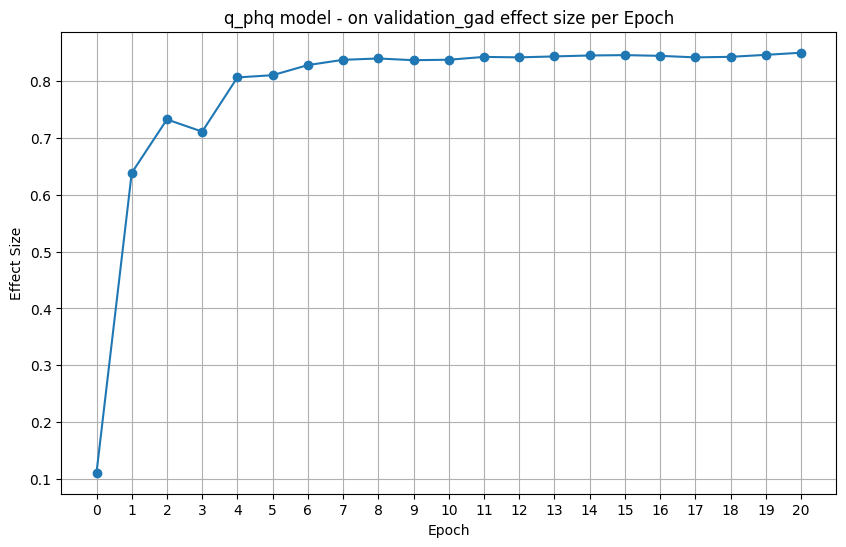

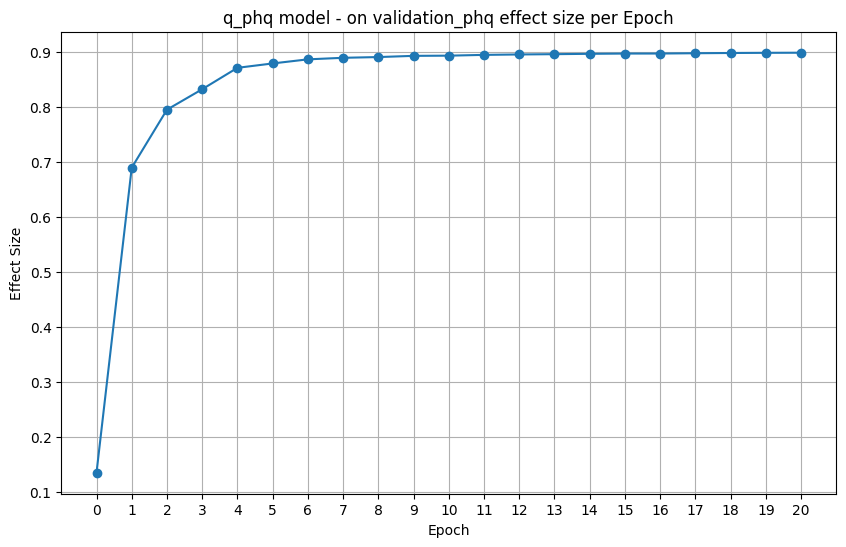

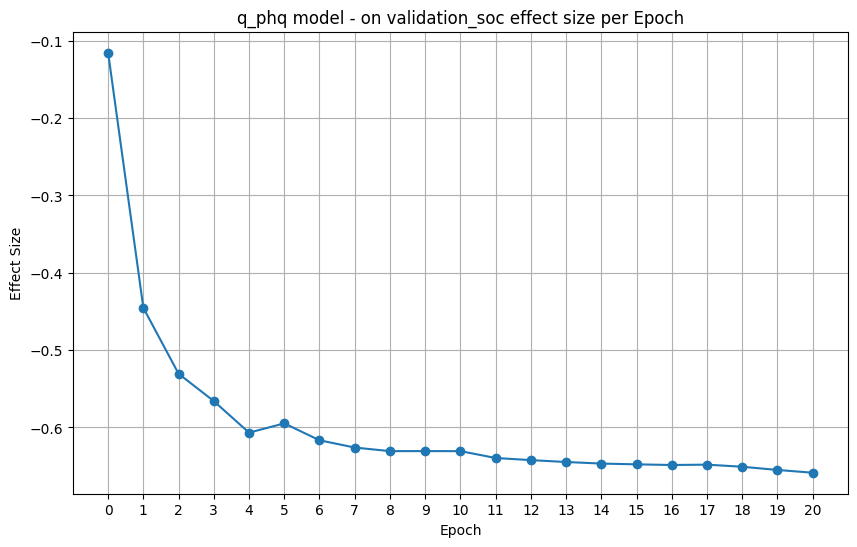

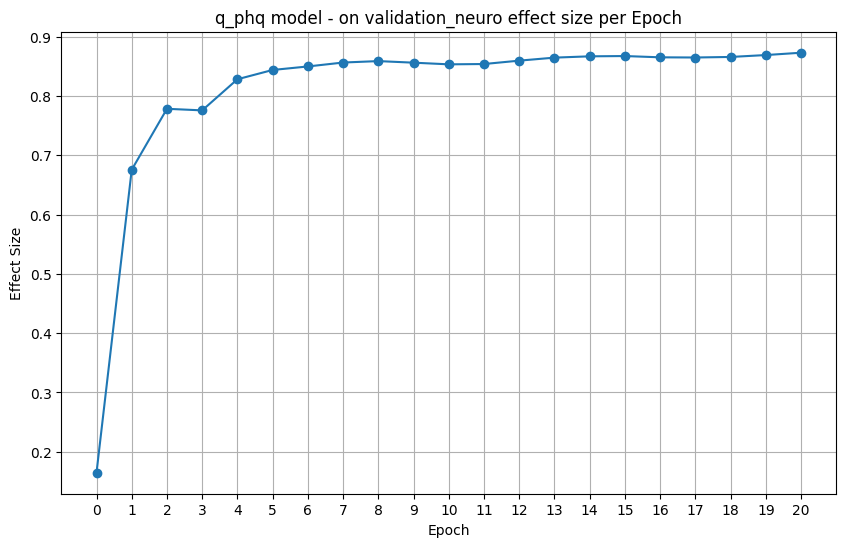

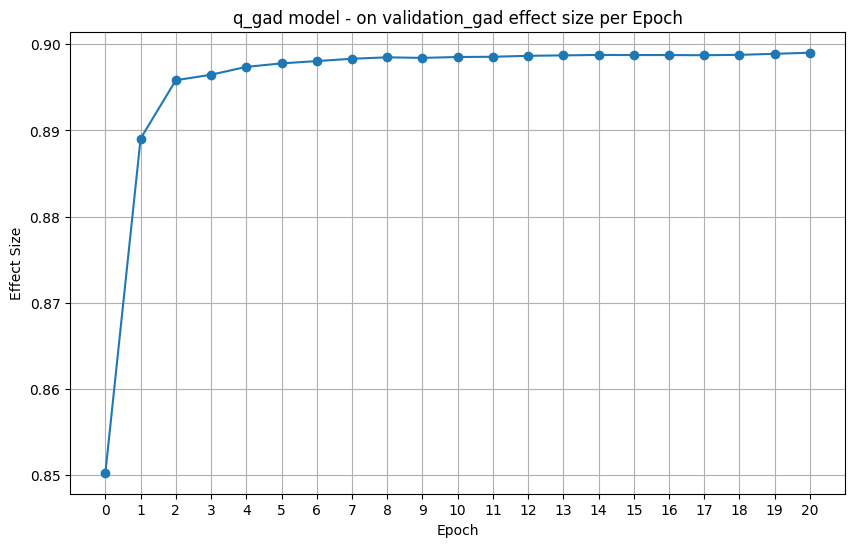

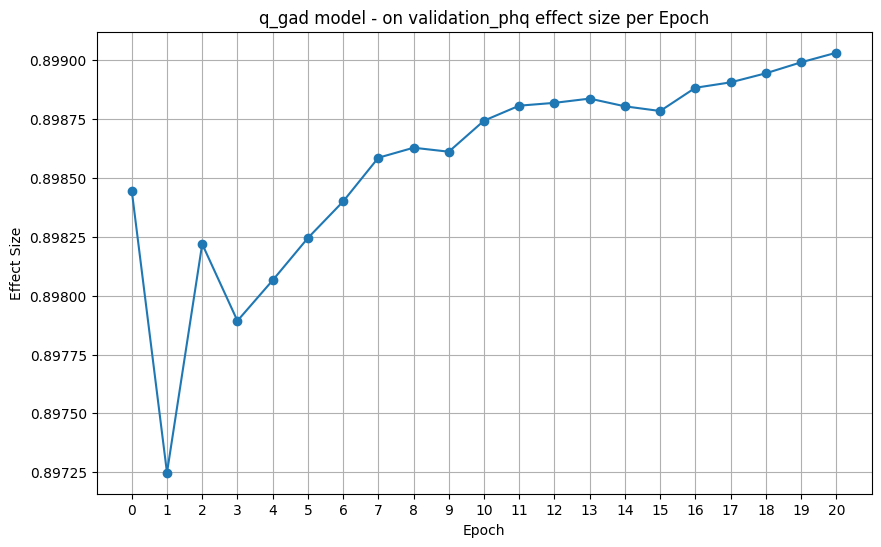

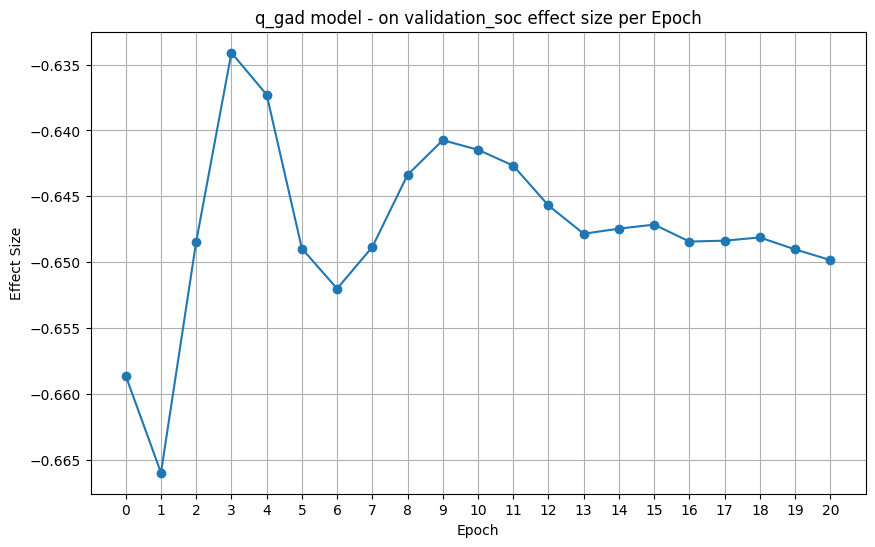

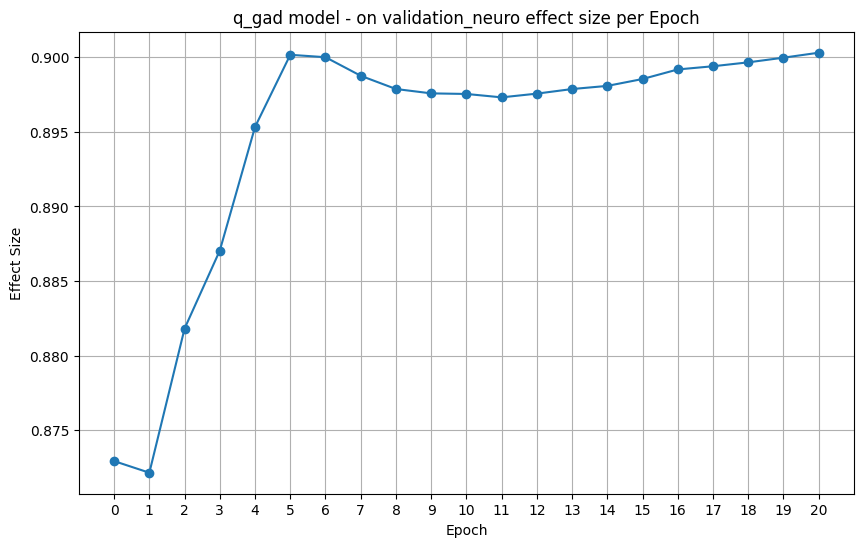

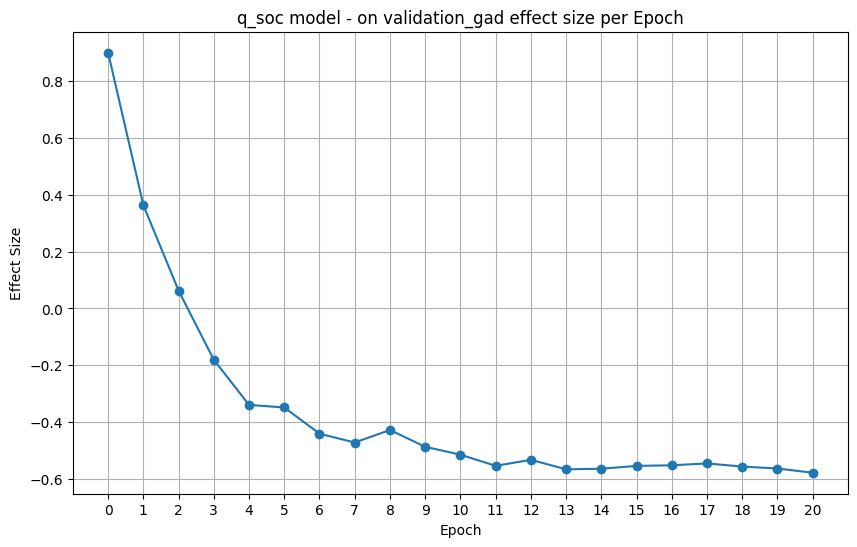

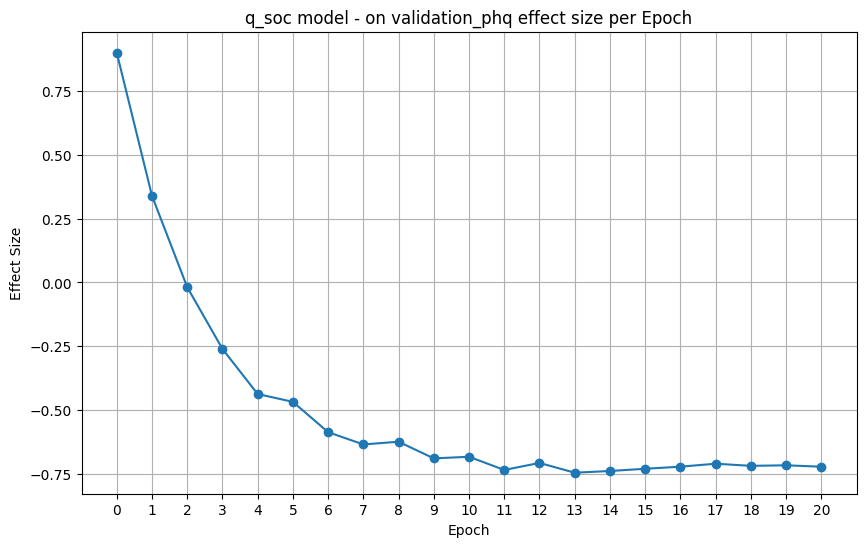

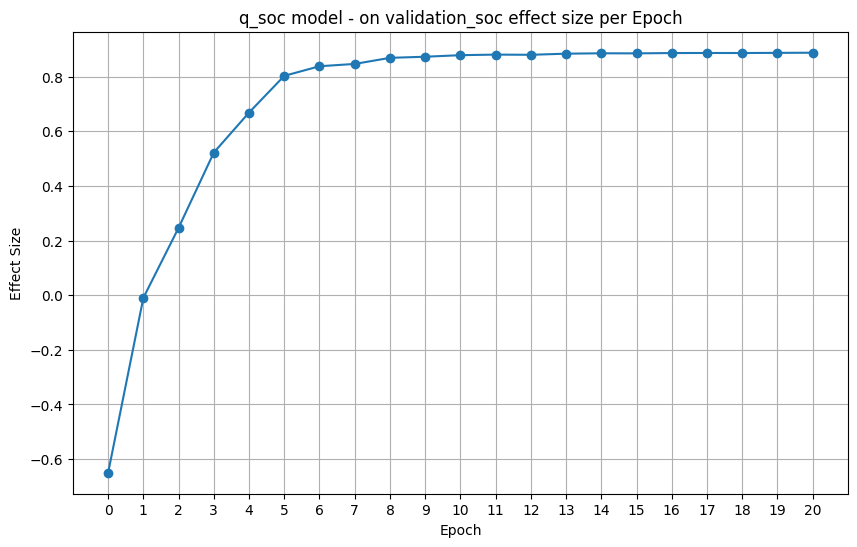

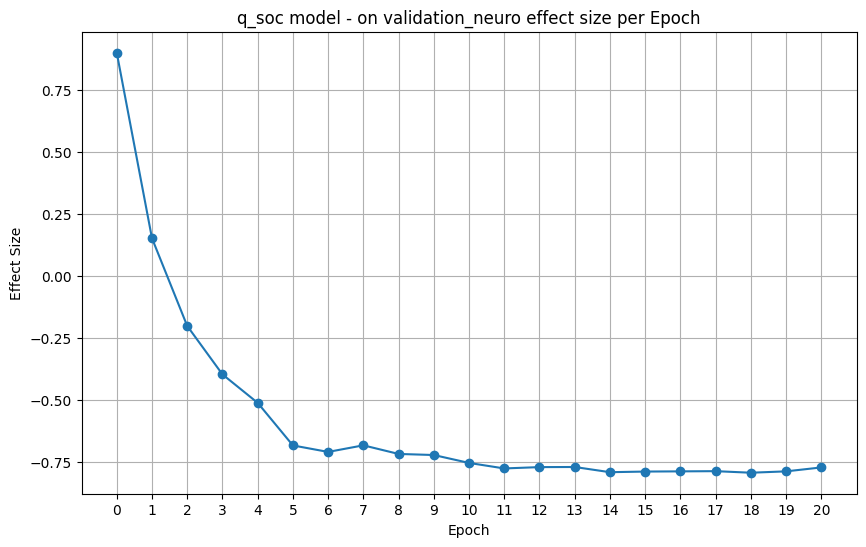

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
# csv_path = '/path/to/your/csvfile.csv'  # Replace with your CSV file path
data = pd.read_csv(output_path)
# data = data[data['model'].isin(models_list)]

# Define model types and validation types
model_types = ['q_phq', 'q_gad', 'q_soc']
# model_types = ['q_soc']
validation_types = ['validation_gad', 'validation_phq', 'validation_soc', 'validation_neuro']
# validation_types = ['nli']
# validation_types = ['validation_neuro']
# validation_types = ['validation_soc']

# Loop through each model type and validation type to calculate mean and create plots
for model_type in model_types:
    for validation_type in validation_types:
        # Filter data for the specific model type and validation type
        filtered_data = data[data['model'].str.contains(model_type) & (data['questionnaire'] == validation_type)]
        
        # Drop columns 'questionnaire' and 'model' to focus only on epochs
        epoch_data = filtered_data.drop(columns=['questionnaire', 'model'])
        
        # Calculate the mean score for each epoch across all rows
        mean_scores = epoch_data.mean(axis=0)
        
        # Plot the mean score over epochs
        plt.figure(figsize=(10, 6))
        plt.plot(mean_scores.index, mean_scores.values, marker='o', linestyle='-')
        plt.title(f'{model_type} model - on {validation_type} effect size per Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Effect Size')
        plt.grid(True)
        
        # Save the plot with a descriptive filename
        plt.savefig(result_path / f'{model_type}_{validation_type}_mlm_all_5_plot_hf.png')
        
        # Optionally, display the plot
        plt.show()


In [57]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [49]:
# # Save the model
# mnli.model.save_pretrained("/dt/puzis/cnalab/karina/distilbert-base-uncased-mnli_e1_phq")
# # Save the tokenizer
# mnli.tokenizer.save_pretrained("/dt/puzis/cnalab/karina/distilbert-base-uncased-mnli_e1_phq")

In [50]:
# # Print gradients after backpropagation
# print("\nGradients after Backpropagation:")
# for name, param in mnli.model.named_parameters():
#     if param.grad is not None:
#         print(f'Gradient for {name}: {param.grad}')
# #     else:
# #         print('None')

# Domain Adapted Models

## MLM

In [43]:
from pathlib import Path

In [44]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1').glob('*checkpoint*')]

In [45]:
pipelines = sorted(pipelines, key=lambda x: int(x.split('epoch-')[1]))
pipelines

['/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-4-epoch-1',
 '/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-8-epoch-2',
 '/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-12-epoch-3',
 '/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-16-epoch-4',
 '/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-20-epoch-5',
 '/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-24-epoch-6',
 '/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-28-epoch-7',
 '/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-32-epoc

In [46]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW
tokenizer = DistilBertTokenizer.from_pretrained("typeform/distilbert-base-uncased-mnli")

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


In [47]:
def validate(model, questions, i, key):
    total_mean_score = 0
#     total_effect_size = 0
    model.model.eval()
    
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(model)
            total_mean_score += q.mean_score()
#             total_effect_size += q.effect_size()
#             total_effect_size += q.effect_size_pos_neg()
        
    avg_val_mean_score = total_mean_score / len(questions)
#     avg_val_mean_score = total_effect_size / len(questions)
    mean_scores[key].append(avg_val_mean_score)
#     print('validate average - mean score: {:.4f}'.format(total_mean_score/len(questions)))

In [48]:
def nli_accuracy(model, validation_data):
    correct = 0
    total = 0
    model.model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for batch in validation_data:
            premise = batch['premise']
            hypothesis = batch['hypothesis']
            label = torch.tensor(batch['label']).to(model.device)  # Convert label to tensor and move to device
            
            inputs = tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, padding=True)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move input tensors to the same device as the model
            
            outputs = model.model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == label).sum().item()
            total += 1

    accuracy = correct / total if total > 0 else 0
    mean_scores['nli'].append(accuracy)
#     return accuracy

In [51]:
def plot_mean_scores(mean_scores, epochs):
    plt.figure(figsize=(10, 8))
    titles = ['Validation PHQ', 'Validation GAD', 'Validation SOC', 'Validation NLI']
    keys = ['validation_phq', 'validation_gad', 'validation_soc', 'nli']
    
    for idx, key in enumerate(keys):
        plt.subplot(2, 2, idx + 1)
        range_plot = list(range(1, 21))
        if key == 'nli':
            plt.title(f'{titles[idx]} Accuracy')
            plt.ylabel('Accuracy')
        else:
            plt.title(f'{titles[idx]} Mean Score')
            plt.ylabel('Mean Score')

        plt.plot(range_plot, mean_scores[key], marker='', label=titles[idx])
        plt.xlabel('Epoch')
        plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

Training Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

pipline: /dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-4-epoch-1


Training Epochs:   5%|▌         | 1/20 [00:49<15:41, 49.55s/it]

pipline: /dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-8-epoch-2


Training Epochs:  10%|█         | 2/20 [01:39<14:51, 49.52s/it]

...

Training Epochs:  90%|█████████ | 18/20 [14:55<01:39, 49.73s/it]

pipline: /dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-76-epoch-19


Training Epochs:  95%|█████████▌| 19/20 [15:46<00:50, 50.16s/it]

pipline: /dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-80-epoch-20


Training Epochs: 100%|██████████| 20/20 [16:36<00:00, 49.84s/it]


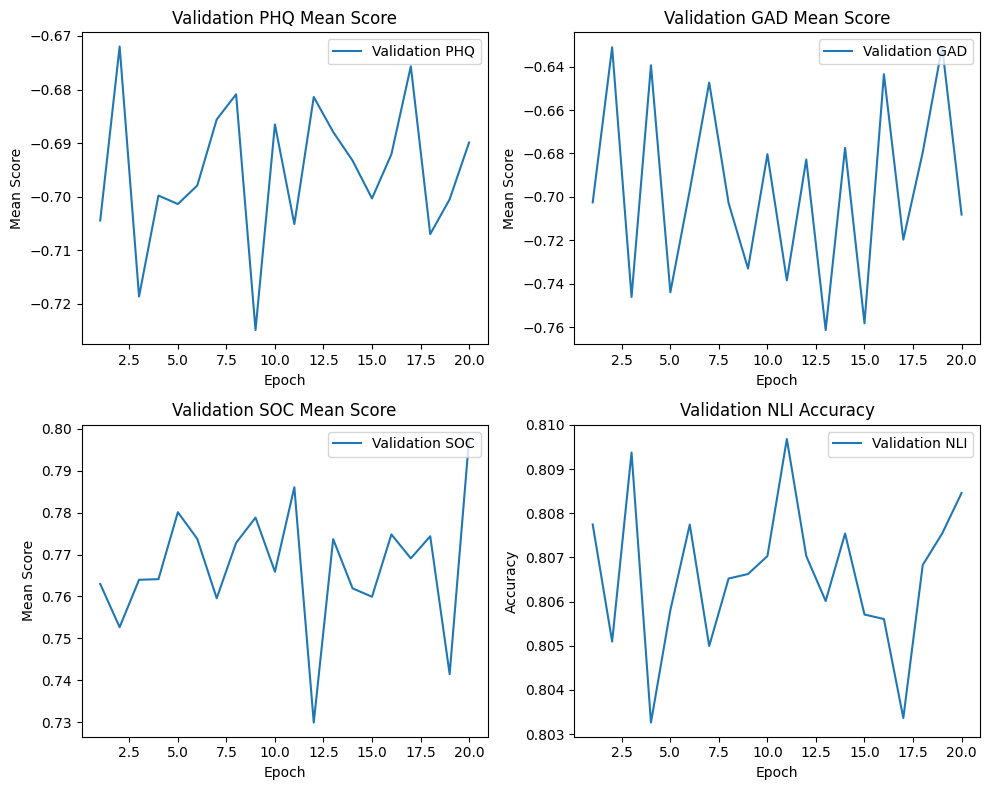

In [52]:
mean_scores = {
    'validation_gad': [],
    'validation_soc': [],
    'validation_phq': [],
    'nli' : []
}

for p in tqdm(pipelines, desc="Training Epochs"):
    print('pipline: {}'.format(p))
    mnli_checkpoint = pipeline("zero-shot-classification", str(Path(p)), device=device)
    mnli_checkpoint.model_identifier = str(Path(p))

    nli_accuracy(mnli_checkpoint, validation_dataset)
        
    validate(mnli_checkpoint, questions_gad, 0, 'validation_gad')
    
    validate(mnli_checkpoint, questions_soc, 0, 'validation_soc')
    
    validate(mnli_checkpoint, questions_phq, 0, 'validation_phq')
    
    torch.cuda.empty_cache()
      
plot_mean_scores(mean_scores, 20)

In [77]:
mlm_models = [
    ('distilbert-base-uncased', 'distilbert', {'entailment':0, 'neutral':1, 'contradiction':2}),
]

In [78]:
base_path = Path('/dt/puzis/cnalab/maor/mnli_models/')
train_file_list = [("high_soc", "high_soc")]
# pipelines=[str(a) for a in Path('/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_depression_run1_unfreeze_mnli').glob('*checkpoint*')]

In [ ]:
lr  = 2e-5
run = 1
epochs = 40
print(base_path)
task = 'mnli'
# task = 'cola'
target_path = base_path
target_path = Path('/dt/puzis/cnalab/maor/mnli_models/')

for train_file, suffix in tqdm(train_file_list):
    print(train_file, suffix)
    for p, model_code, label_2_id in tqdm(mlm_models, desc='run models'):  
        p = str(p)
        temp_p = p
        input_dir = base_path / f'mlm_st_{temp_p.replace("/", "")}_{str(lr).replace("-", "")}_{suffix}_run{run}/'
        output_dir = target_path / f'mlm_st_{temp_p.replace("/", "")}_{str(lr).replace("-", "")}_{suffix}_run{run}_unfreeze_{task}_{run}/'
        if input_dir.exists():
            if len(list(input_dir.glob('checkpoint-*'))) >= epochs:
                print('skip:', p)
                continue
            else:
                print('rerun:', p)
        base_model_name = temp_p.replace('/mnli_models/', '').replace('_bgu_mnli', '').replace('_', '/', 1)
        print('base_model_name:', base_model_name)
        for mlm_check_point in tqdm(list(input_dir.glob('checkpoint-*'))):
#         for mlm_check_point in tqdm([Path('checkpoint-0-epoch-0')]):
            output_mnli_path = output_dir / mlm_check_point.name
            if mlm_check_point.name == 'checkpoint-0-epoch-0':
                mlm_check_point = p
                print(mlm_check_point)
            print(output_mnli_path)
            if output_mnli_path.exists():
                print('skip:', output_mnli_path)
            script = f"""
            python run_glue.py \
                --model_name_or_path "{str(mlm_check_point)}" \
                --task_name {task} \
                --fp16 True \
                --do_train True \
                --do_eval True \
                --save_strategy no \
                --num_train_epochs 1 \
                --overwrite_output_dir False \
                --report_to none \
                --per_device_train_batch_size 32 \
                --per_device_eval_batch_size 32 \
                --output_dir "{str(output_mnli_path)}" """
            os.system(script)


/dt/puzis/cnalab/maor/mnli_models


  0%|          | 0/1 [00:00<?, ?it/s]

high_soc high_soc



run models:   0%|          | 0/1 [00:00<?, ?it/s]

rerun: distilbert-base-uncased
base_model_name: distilbert-base-uncased


...



 80%|████████  | 16/20 [2:59:55<45:00, 675.02s/it]

/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1/checkpoint-12-epoch-3


2024-10-28 13:20:19.549992: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-28 13:20:20.966863: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


10/28/2024 13:20:25 - WARNING - __main__ - Process rank: 0, device: cuda:0, n_gpu: 1distributed training: True, 16-bits training: True


/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/datasets/load.py:2483: FutureWarning: 'use_auth_token' was deprecated in favor of 'token' in version 2.14.0 and will be removed in 3.0.0.
You can remove this warning by passing 'token=<use_auth_token>' instead.
  warnings.warn(
[WARNING|modeling_utils.py:4282] 2024-10-28 13:20:38,487 >> Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at /dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1/checkpoint-12-epoch-3 and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 93%|█████████▎| 11375/12272 [09:18<00:43, 20.71it/s]